In [226]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In this homework, we will use the Car price dataset like last week. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv).

Or you can do it with `wget`:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
```

We'll work with the `MSRP` variable, and we'll transform it to a classification task. 

For the rest of the homework, you'll need to use only these columns:

* `Make`,
* `Model`,
* `Year`,
* `Engine HP`,
* `Engine Cylinders`,
* `Transmission Type`,
* `Vehicle Style`,
* `highway MPG`,
* `city mpg`,
* `MSRP`


### Data preparation

* Keep only the columns above
* Lowercase the column names and replace spaces with underscores
* Fill the missing values with 0 
* Make the price binary (1 if above the average, 0 otherwise) - this will be our target variable `above_average`

Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use `train_test_split` function for that with `random_state=1`

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv

--2024-10-03 02:26:37--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8001::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2024-10-03 02:26:38 (11.3 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [3]:
df = pd.read_csv('data.csv')


In [4]:
df.columns.to_list()

['Make',
 'Model',
 'Year',
 'Engine Fuel Type',
 'Engine HP',
 'Engine Cylinders',
 'Transmission Type',
 'Driven_Wheels',
 'Number of Doors',
 'Market Category',
 'Vehicle Size',
 'Vehicle Style',
 'highway MPG',
 'city mpg',
 'Popularity',
 'MSRP']

In [7]:
cols = ['Make',
 'Model',
 'Year',
 'Engine HP',
 'Engine Cylinders',
 'Transmission Type',
 'Vehicle Style',
 'highway MPG',
 'city mpg',
 'MSRP']

df = df[cols]
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [8]:
df.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg,msrp
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,34500


In [10]:
df = df.fillna(0)

In [12]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_hp            0
engine_cylinders     0
transmission_type    0
vehicle_style        0
highway_mpg          0
city_mpg             0
msrp                 0
dtype: int64

In [13]:
df['above_average'] = (df['msrp'] > df['msrp'].mean()).astype('int')

In [14]:
df.head()

,make,model,year,engine_hp,engine_cylinders,transmission_type,vehicle_style,highway_mpg,city_mpg,msrp,above_average
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,Coupe,26,19,46135,1
1,BMW,1 Series,2011,300.0,6.0,MANUAL,Convertible,28,19,40650,1
2,BMW,1 Series,2011,300.0,6.0,MANUAL,Coupe,28,20,36350,0
3,BMW,1 Series,2011,230.0,6.0,MANUAL,Coupe,28,18,29450,0
4,BMW,1 Series,2011,230.0,6.0,MANUAL,Convertible,28,18,34500,0


In [24]:
df.columns.to_list()

['make',
 'model',
 'year',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'msrp',
 'above_average']

In [26]:
# does not include the target variables
features = ['make',
 'model',
 'year',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'vehicle_style',
 'highway_mpg',
 'city_mpg']

In [47]:


def split_data(df, features=features):
    df = df.copy()
    y_full = df['above_average'].values
    
    #remove the targets
    # df = df[features]

    df_train_full, df_test, y_train_full, y_test = train_test_split(df[features], y_full, test_size=0.2, random_state=1)
    df_train, df_val, y_train, y_val = train_test_split(df_train_full, y_train_full, test_size=0.25, random_state=1)

    return df_train, df_val, df_test, y_train, y_val, y_test

    

In [48]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, features=features)

In [49]:
assert len(df_train) == len(y_train)
assert len(df_val) == len(y_val) == len(df_test) == len(y_test)


### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score and compute AUC with the `above_average` variable
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['engine_hp']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `engine_hp`
- `engine_cylinders`
- `highway_mpg`
- `city_mpg`

In [33]:
from sklearn.metrics import roc_auc_score

In [50]:
for c in ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg']:
    auc = roc_auc_score(y_train, df_train[c])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    print(f"feature: {c} ----> roc_auc_score {auc}")

feature: engine_hp ----> roc_auc_score 0.9171031265539011
feature: engine_cylinders ----> roc_auc_score 0.766116490165669
feature: highway_mpg ----> roc_auc_score 0.6330587871772013
feature: city_mpg ----> roc_auc_score 0.6734244643245233


### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.678
- 0.779
- 0.878
- 0.979

In [64]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [76]:
def train_log_reg(df_train, df_val, y_train, y_val):
    train_dicts = df_train.to_dict(orient='records')
    val_dicts = df_val.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)

    X_train = dv.fit_transform(train_dicts)
    X_val = dv.transform(val_dicts)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
    #y_pred = model.predict(X_val)
    y_pred = model.predict_proba(X_val)[:, 1]

    auc = round(roc_auc_score(y_val, y_pred), 3)

    return auc

    

In [77]:
train_log_reg(df_train, df_val, y_train, y_val)

0.976

### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

* 0.28
* 0.48
* 0.68
* 0.88

In [90]:
dicts_train = df_train.to_dict(orient='records')
dicts_val = df_val.to_dict(orient='records')

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(dicts_train)
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

X_val = dv.transform(dicts_val)
y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
auc

0.976132108676773

In [115]:
#for t in np.linspace(0, 1.01, 101):
def compute_prec_rec(y_val=y_val, y_pred=y_pred):
    scores = []
    
    for t in np.linspace(0, 1, 101):
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
    
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
    
        tp = (predict_positive & actual_positive).sum()
        fp = (predict_positive & actual_negative).sum()
        tn = (predict_negative & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        abs_diff = abs(prec - rec)
        scores.append([t, prec, rec, abs_diff])
        
    
    cols = ['threshold', 'precision', 'recall', 'abs_difference']
    df_scores = pd.DataFrame(scores, columns=cols)
    
    return df_scores

In [116]:
df_scores = compute_prec_rec(y_val=y_val, y_pred=y_pred)

/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_24069/2918101915.py:17: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_24069/1129470827.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


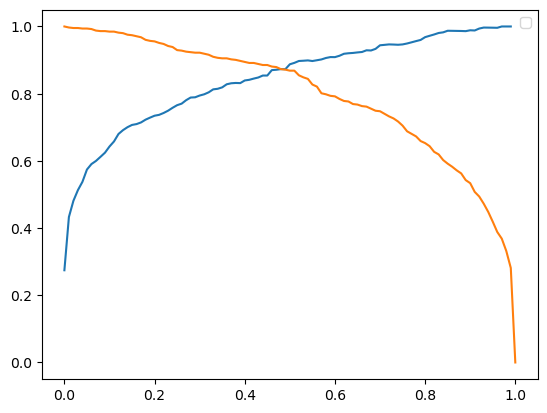

In [113]:
plt.plot(df_scores['threshold'], df_scores['precision'], )
plt.plot(df_scores['threshold'], df_scores['recall'])


plt.show()

In [122]:
df_scores.iloc[df_scores['abs_difference'].idxmin()].threshold

0.48

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.12
- 0.32
- 0.52
- 0.72

In [124]:
def compute_f1_score(y_val=y_val, y_pred=y_pred):
    scores = []
    
    for t in np.linspace(0, 1, 101):
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
    
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
    
        tp = (predict_positive & actual_positive).sum()
        fp = (predict_positive & actual_negative).sum()
        tn = (predict_negative & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
    
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        abs_diff = abs(prec - rec)
        f1 = 2 * ((prec * rec) / (prec + rec))
        
        scores.append([t, prec, rec, abs_diff, f1])
        
    
    cols = ['threshold', 'precision', 'recall', 'abs_difference', 'f1_score']
    df_scores = pd.DataFrame(scores, columns=cols)
    
    return df_scores

In [129]:
df_f1_scores = compute_f1_score(y_val=y_val, y_pred=y_pred)
max_f1_threshold = df_f1_scores.iloc[df_f1_scores['f1_score'].idxmax()].threshold

# print(f"The thresshold at which f1 is at its max is {max_f1_threshold}")
max_f1_threshold

/var/folders/v9/93rc7dfs375c0pyff8wx6c6h0000gn/T/ipykernel_24069/3075202359.py:16: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


0.51

answer: the closest is 0.52

In [136]:
df_f1_scores.loc[df_f1_scores.f1_score.argmax()]

threshold         0.510000
precision         0.891680
recall            0.868502
abs_difference    0.023178
f1_score          0.879938
Name: 51, dtype: float64

### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.003
- 0.030
- 0.090
- 0.140

In [137]:
from sklearn.model_selection import KFold

In [179]:
def split_train_full(df):
    df = df.copy()
    df_full_train, df_test, y_full_train, y_test = train_test_split(df, df['above_average'], shuffle=True, random_state=1)

    return df_full_train, df_test, y_full_train, y_test

In [180]:
df_full_train, df_test, y_full_train, y_test = split_train_full(df)

assert len(df_full_train) == len(y_full_train)
assert len(df_test) == len(y_test)

In [181]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

In [223]:
def train_kfold_2(df_full_train, y_full_train, C=1.0):
    scores = []
    
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
    
        y_train = y_full_train.iloc[train_idx]
        y_val = y_full_train.iloc[val_idx]

        df_train = df_train.drop(['msrp', 'above_average'], axis=1)
        df_val = df_val.drop(['msrp', 'above_average'], axis=1)

        
    
        dv = DictVectorizer()
        train_dicts = df_train.to_dict(orient='records')
        val_dicts = df_val.to_dict(orient='records')
        X_train = dv.fit_transform(train_dicts)
        X_val = dv.transform(val_dicts)
    
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    # print(scores)
    # print()
    return f"mean_auc: {np.mean(scores):<10.3f} <--- std: {np.std(scores):<10.5f}"

In [224]:
train_kfold_2(df_full_train, y_full_train)

'mean_auc: 0.975      <--- std: 0.00198   '

answer: the closest resoonse is 0.003

### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.01, 0.1, 0.5, 10]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

- 0.01
- 0.1
- 0.5
- 10

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [233]:
for C in [0.01, 0.1, 0.5, 10]:
    print(f"C : {C}  {train_kfold_2(df_full_train, y_full_train, C)}")

C : 0.01  mean_auc: 0.951      <--- std: 0.00284   
C : 0.1  mean_auc: 0.970      <--- std: 0.00280   
C : 0.5  mean_auc: 0.976      <--- std: 0.00231   
C : 10  mean_auc: 0.981      <--- std: 0.00391   


answer: 10

In [227]:
!git branch

  hw-1
  hw2
* master
  week3


In [228]:
!git checkout -b week4

Switched to a new branch 'week4'


In [229]:
!git add homework_4_old.ipynb

In [230]:
!git commit -m "shifted work to week4 branch"

[week4 ddeeff9] shifted work to week4 branch
 1 file changed, 1265 insertions(+)
 create mode 100644 cohorts/2024/04-evaluation/homework_4_old.ipynb


In [231]:
!git push origin week4

Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 8 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 28.29 KiB | 5.66 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
remote: 
remote: Create a pull request for 'week4' on GitHub by visiting:
remote:      https://github.com/idh71/machine-learning-zoomcamp/pull/new/week4
remote: 
To github.com:idh71/machine-learning-zoomcamp.git
 * [new branch]      week4 -> week4


In [232]:
!git status


On branch week4
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../01-intro/homework-1/
	data.csv

nothing added to commit but untracked files present (use "git add" to track)
